Import all the libraries

In [66]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, Literal
from pydantic import BaseModel, Field
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, SystemMessage
import operator

In [67]:
load_dotenv()

True

Defining different llms according to the task
1. Generator LLM
2. Evaluator LLM
3. Optimizer LLM

In [68]:
generator_llm = ChatGroq(model="llama-3.3-70b-versatile")
evaluator_llm = ChatGroq(model="LLaMA-3.1-8B-Instant")
optimizer_llm = ChatGroq(model="openai/gpt-oss-120b")

Defining State

In [69]:
class XPostGenrationState(TypedDict):

    topic: str
    x_post_content: str
    evaluation: Literal["approved", "needs_improvement"]
    post_feedback: str
    iteration: int
    max_iterations: int
    x_post_content_history: Annotated[list[str], operator.add]
    post_feedback_history: Annotated[list[str], operator.add]

In [70]:
class PostEvaluationSchema(BaseModel):
    
    evaluation: Literal["approved", "needs_improvement"] = Field(
        description="The evaluation result of the X post content."
    )
    post_feedback: str = Field(
        description="Detailed feedback on the X post content."
    )

In [71]:
structured_evaluation_llm = evaluator_llm.with_structured_output(PostEvaluationSchema)

Defining all the nodes and conditional function

In [72]:
def generate_x_post_content(state: XPostGenrationState):

    prompt = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

Rules:
- Do NOT use question-answer format.
- Max 280 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english
""")
    ]

    response = generator_llm.invoke(prompt).content
    return {"x_post_content": response, "x_post_content_history": [response]}

In [73]:
def evaluate_x_post_content(state: XPostGenrationState):

    prompt = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{state['x_post_content']}"

Use the criteria below to evaluate the tweet:

1. Originality – Is this fresh, or have you seen it a hundred times before?  
2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
3. Punchiness – Is it short, sharp, and scroll-stopping?  
4. Virality Potential – Would people retweet or share it?  
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"  
- feedback: One paragraph explaining the strengths and weaknesses 
""")
]
    
    response = structured_evaluation_llm.invoke(prompt)

    return {"evaluation": response.evaluation, "post_feedback": response.post_feedback, "post_feedback_history": [response.post_feedback]}

In [74]:
def optimize_x_post_content(state: XPostGenrationState):

    prompt = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['post_feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['x_post_content']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]

    response = optimizer_llm.invoke(prompt).content
    iteration = state['iteration'] + 1

    return {"x_post_content": response, "x_post_content_history": [response], "iteration": iteration}

In [75]:
# Conditional function

def check_evaluation(state: XPostGenrationState):

    if state['evaluation'] == "approved":
        return "approved"
    else:
        return "needs_improvement"

Graph Creation

In [76]:
graph = StateGraph(XPostGenrationState)

Adding nodes, edges and conditional edges

In [77]:
graph.add_node("x_post_generation", generate_x_post_content) # 1st field within the bracket is the name of the node and secnd the is the function to be applied and run inside that node.
graph.add_node("x_post_evaluation", evaluate_x_post_content)
graph.add_node("x_post_optimization", optimize_x_post_content)


graph.add_edge(START, "x_post_generation")
graph.add_edge("x_post_generation", "x_post_evaluation")# both are the name of the nodes added above.
graph.add_conditional_edges("x_post_evaluation", check_evaluation, {"approved": END, "needs_improvement": "x_post_optimization"}) 
graph.add_edge("x_post_optimization", "x_post_evaluation")

Compiling Graph

In [78]:
workflow = graph.compile()

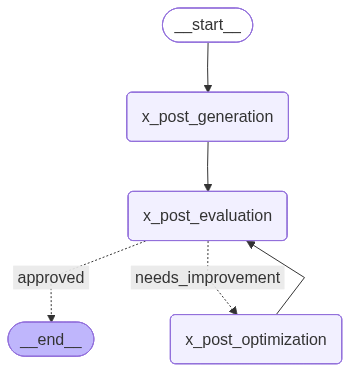

In [79]:
workflow

In [111]:
initial_state ={
    "topic": "Transformers and their role in modern AI",
    "iteration": 1,
    "max_iterations": 5
    }

result = workflow.invoke(initial_state)

In [112]:
result

{'topic': 'Transformers and their role in modern AI',
 'x_post_content': '"Transformers are taking over AI and honestly, I\'m just waiting for Optimus Prime to judge my Netflix binge-watching habits" #AI #Transformers',
 'evaluation': 'approved',
 'post_feedback': 'Original and humorous, the tweet combines a relatable observation with a playful reference to Optimus Prime, creating a unique and engaging experience. However, the potential for virality could be increased by simplifying the format and making the punchline more concise. Additionally, the use of hashtags is a good touch, but consider adding more context to make the tweet more accessible to a broader audience.',
 'iteration': 1,
 'max_iterations': 5,
 'x_post_content_history': ['"Transformers are taking over AI and honestly, I\'m just waiting for Optimus Prime to judge my Netflix binge-watching habits" #AI #Transformers'],
 'post_feedback_history': ['Original and humorous, the tweet combines a relatable observation with a pla